In [6]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)


       MedInc  HouseAge  AveRooms  MedHouseVal
0      8.3252      41.0  6.984127        4.526
1      8.3014      21.0  6.238137        3.585
2      7.2574      52.0  8.288136        3.521
3      5.6431      52.0  5.817352        3.413
4      3.8462      52.0  6.281853        3.422
...       ...       ...       ...          ...
20635  1.5603      25.0  5.045455        0.781
20636  2.5568      18.0  6.114035        0.771
20637  1.7000      17.0  5.205543        0.923
20638  1.8672      18.0  5.329513        0.847
20639  2.3886      16.0  5.254717        0.894

[20640 rows x 4 columns]
Normality Check p-value: 0.0000
Result: Not Normal (Typical for real-world data)

Correlation Matrix:


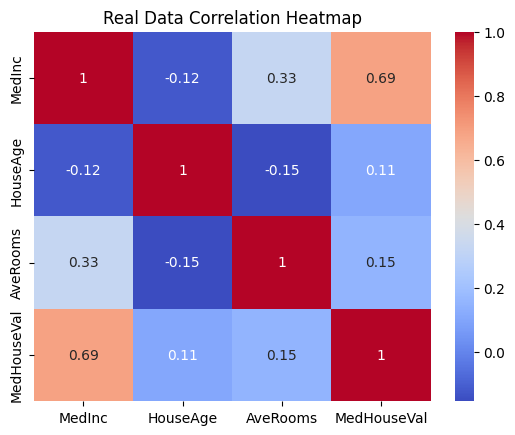


VIF Scores:
     feature       VIF
0    MedInc  4.836358
1  HouseAge  3.218787
2  AveRooms  4.987324

Durbin-Watson: 0.0732 (Ideal is ~2.0)

--- Model Performance ---
MAE: 0.6033
MSE: 0.6589
R-squared: 0.4972


In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Load Real Dataset
"""
What’s happening: We are fetching a famous real-world dataset. The as_frame=True argument converts the raw NumPy arrays into a Pandas 
DataFrame.
Backend: Scikit-learn downloads a .csv.gz file (if not already cached), unzips it, and maps the columns to the specified header names. 
Selecting specific columns reduces the dimensionality, making our diagnostic checks easier to interpret.
"""
housing = fetch_california_housing(as_frame=True)
df = housing.frame
# For simplicity in 'Simple' Linear Regression, we'll focus on a few key numeric features
df = df[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']]
print(df)
# --- PRE-SPLIT CHECKS ---

# A. Normal Distribution Check (Target: MedHouseVal)
# Note: Real data often fails this; large datasets may use D'Agostino's K^2
"""
What’s happening: We are performing D’Agostino’s test.
Backend: This calculates the Skewness (how lopsided the data is) and Kurtosis (how "fat" the tails are) of your target variable.
The Math: It compares your data's shape to a perfect Bell Curve. If the p_value < 0.05, 
the backend is saying: "The probability that this data came from a normal distribution is nearly zero."
"""
_, p_val = stats.normaltest(df['MedHouseVal'])
print(f"Normality Check p-value: {p_val:.4f}")
print("Result:", "Normal" if p_val > 0.05 else "Not Normal (Typical for real-world data)")

# B. Data Correlation
print("\nCorrelation Matrix:")
"""
3. Data Correlation (Pearson’s Coefficient)
The Code:
df.corr()
What is happening in the backend:
The backend calculates the linear relationship between every pair of variables. It determines how much one variable changes when another does.
The Formula:
check formula for Correlation (Pearson’s Coefficient) on google
Interpretation: A result of +1.0 is a perfect positive correlation, -1.0 is a perfect negative correlation, and 0 means no relationship.
"""
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Real Data Correlation Heatmap")
plt.show()

# C. Multicollinearity (VIF)
"""
4. Multicollinearity (Variance Inflation Factor - VIF)
The Code:
variance_inflation_factor(X.values, i)
What is happening in the backend:
VIF detects if two or more independent variables are "telling the same story." The backend runs a hidden regression where one feature is treated as the target against the others.
The Formula: VIF = 1/1-(R)squared
Backend Logic: If the R square of that hidden regression is high (e.g., 0.90), the VIF will be 10. 
This tells you that the feature is redundant.
"""
X_check = df.drop('MedHouseVal', axis=1)
vif_df = pd.DataFrame()
vif_df["feature"] = X_check.columns
vif_df["VIF"] = [variance_inflation_factor(X_check.values, i) for i in range(len(X_check.columns))]
print("\nVIF Scores:\n", vif_df)

# D. Redundancy & Data Leakage Check
# Check if any feature has a correlation of 1.0 with the target (leakage)

correlations = df.corr()['MedHouseVal'].abs()
leakage = correlations[correlations > 0.95].index.tolist()
leakage.remove('MedHouseVal')
if leakage: print(f"Potential Leakage in: {leakage}")

# E. Auto-correlation (Durbin-Watson)
"""
Auto-correlation (Durbin-Watson Test)
The Code:
durbin_watson(df['Target'])
What is happening in the backend:
This checks for "serial correlation" between rows. It is vital to ensure that the value of one row doesn't influence the next (which would violate the independence of data).
Result: A value of 2.0 means no auto-correlation. Values closer to 0 mean the data is highly dependent on previous observations.

"""
dw_stat = durbin_watson(df['MedHouseVal'])
print(f"\nDurbin-Watson: {dw_stat:.4f} (Ideal is ~2.0)")

# --- MODEL BUILDING ---

# 2. Train-Test Split
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Prediction
y_pred = model.predict(X_test)

# 5. Performance Metrics
print("\n--- Model Performance ---")
print(f"MAE: {metrics.mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE: {metrics.mean_squared_error(y_test, y_pred):.4f}")
print(f"R-squared: {metrics.r2_score(y_test, y_pred):.4f}")
